# Goal
Show simple cross matching.
Additionally: we could train an ML model to have a showcase what's possible with this data.

#### What is the Multi-modal Universe (MMU)?

The Multi-modal Universe (MMU) is a framework designed to facilitate the exploration and analysis of astronomical data across multiple wavelengths and modalities. It aims to provide a unified platform for accessing, processing, and visualizing diverse datasets, enabling researchers to gain deeper insights into the universe's structure and evolution. We refer the interested reader to [the arxiv paper](https://arxiv.org/pdf/2412.02527).

The whole MMU is uploaded to huggingface at: https://huggingface.co/collections/UniverseTBD/multimodal-universe-lsdb-hats

#### What do the catalogs contain?
In this demo we load data from the Gaia and Chandra catalog.

##### Chandra Catalogue
Chandra is NASA's X-ray Observatory catalog containing over 1.3 million X-ray source detections across the sky, providing spectral, photometric, and temporal properties of high-energy astronomical objects like black holes, supernova remnants, and active galactic nuclei.

**Use cases:** Studying extreme astrophysical environments (accreting black holes, X-ray binaries, hot stars), enabling multi-wavelength astronomy by crossmatching X-ray sources with optical/infrared surveys to identify counterparts and understand the physical nature of energetic cosmic phenomena.

**Official documentation:** [Chandra Source Catalog Release 2.1](https://cxc.cfa.harvard.edu/csc/)

##### Gaia Catalogue
Gaia DR3 is ESA's comprehensive astrometric survey containing precise 3D positions, velocities, and photometry for over 1.8 billion stars in our galaxy, with additional spectroscopic data for millions of objects including radial velocities and astrophysical parameters.

**Use cases:** Galactic archaeology and stellar evolution studies by mapping the Milky Way's structure and dynamics, precise distance measurements and proper motions for calibrating cosmic distance ladders, identifying stellar populations, detecting binary systems, and serving as an all-sky reference catalog for crossmatching with other astronomical surveys.

**Official documentation:** [Gaia DR3 Documentation](https://gea.esac.esa.int/archive/documentation/GDR3/) | [Gaia DR3 Overview](https://www.cosmos.esa.int/web/gaia/dr3)

#### What is cross-matching?
Catalogs can be quite large, and astronomical sources are typically identified by position and given a unique identifier that is not consistent across catalogs. To combine knowledge from multiple catalogs, we need to find objects that are reasonably close to each other (to account for measurement errors and positional uncertainties). This process is exactly what crossmatching does - it identifies likely counterparts between different surveys based on spatial proximity.

In [7]:
!uv pip install lsdb matplotlib

Using Python 3.13.8 environment at: /home/tobias/programming/github/mmu-hdf-to-hats/.venv
Resolved 70 packages in 159ms                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)--------------     0 B/8.38 MiB            
⠙ Preparing packages... (0/2)-------------- 14.83 KiB/8.38 MiB          
⠙ Preparing packages... (0/2)-------------- 30.83 KiB/8.38 MiB          
⠙ Preparing packages... (0/2)-------------- 46.83 KiB/8.38 MiB          
⠙ Preparing packages... (0/2)-------------- 62.83 KiB/8.38 MiB          
⠙ Preparing packages... (0/2)-------------- 78.83 KiB/8.38 MiB          
⠙ Preparing packages... (0/2)-------------- 94.83 KiB/8.38 MiB          
⠙ Preparing packages... (0/2)-------------- 110.83 KiB/8.38 MiB         
⠙ Preparing packages... (0/2)-------------- 126.83 KiB/8.38 MiB         
⠙ Preparing packages... (0/2)-------------- 142.83 KiB/8.38 MiB         
⠙ Preparing packages... (0/2)

In [4]:
import lsdb

# We use only specific healpixels to speed up the demo
pixel_filter = lsdb.PixelSearch((4, 1801))

# Open the Gaia catalog, and filter to reduce the data to download.
gaia = lsdb.open_catalog(
    "hf://datasets/UniverseTBD/mmu_gaia_gaia",
    search_filter=pixel_filter,
)

# Same for Chandra (we are using the spectra catalog here, but it doesn't matter which one we use as long as it overlaps with Gaia).
chandra = lsdb.open_catalog(
    "hf://datasets/UniverseTBD/mmu_chandra_spectra",
    search_filter=pixel_filter,
)
# Crossmatch the two catalogs. This will download the relevant data and perform the crossmatch.
matched = chandra.crossmatch(gaia, radius_arcsec=5.0)
result = matched.compute()

/home/tobias/programming/github/mmu-hdf-to-hats/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tobias/programming/github/mmu-hdf-to-hats/.venv/lib/python3.13/site-packages/lsdb/catalog/catalog.py:358: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(
Computing Catalog:  72%|███████▏  | 575/800 [00:21<00:05, 44.11it/s]/home/tobias/programming/github/mmu-hdf-to-hats/.venv/lib/python3.13/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is d

In [5]:
# We have 668 matches in this healpix. Note that we chose this healpix on purpose due to its high match count,
# so this is not representative of the typical match count per healpix, which is much lower.
print(f"Number of crossmatched sources: {len(result)}")
print(f"\nFirst few matches:")
result[["ra_mmu_chandra_spectra", "dec_mmu_chandra_spectra", 
        "ra_mmu_gaia_gaia", "dec_mmu_gaia_gaia", "_dist_arcsec"]].head()

Number of crossmatched sources: 668

First few matches:


,ra_mmu_chandra_spectra,dec_mmu_chandra_spectra,ra_mmu_gaia_gaia,dec_mmu_gaia_gaia,_dist_arcsec
_healpix_29,,,,,
2027901084589563194,266.598665,-31.583626,266.598653,-31.583595,0.118445
2027901084589563194,266.598665,-31.583626,266.598653,-31.583595,0.118445
2027940240246692742,266.475022,-31.250956,266.475057,-31.250963,0.109935
2027950185158122865,266.388735,-30.982539,266.388522,-30.982385,0.859279
2027958213093541661,267.319017,-31.255031,267.318988,-31.255028,0.089985


Computing Catalog:  72%|███████▏  | 579/800 [00:20<00:06, 32.82it/s]/home/tobias/programming/github/mmu-hdf-to-hats/.venv/lib/python3.13/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])
Computing Catalog:  74%|███████▍  | 591/800 [00:20<00:04, 43.61it/s]/home/tobias/programming/github/mmu-hdf-to-hats/.venv/lib/python3.13/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margi

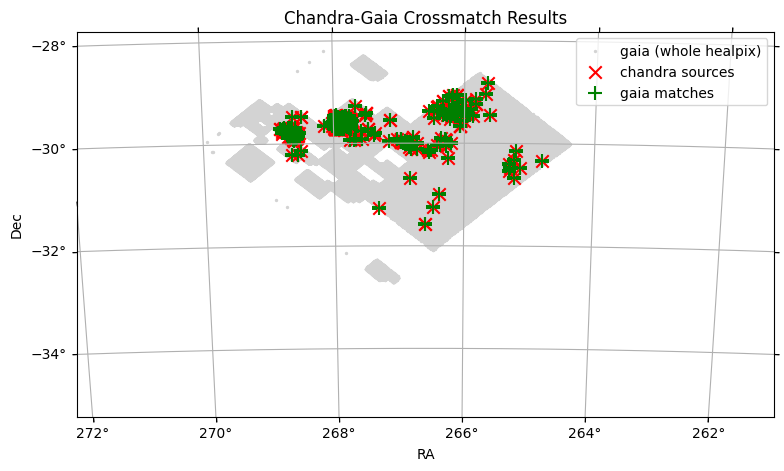

In [8]:
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord

ra0 = float(result["ra_mmu_chandra_spectra"].iloc[0])
dec0 = float(result["dec_mmu_chandra_spectra"].iloc[0])
center = SkyCoord(ra0 * u.deg, dec0 * u.deg)
fov = (500 * u.arcmin, 500 * u.arcmin)

# Background: all Gaia points in the partition, for context.
fig, ax = gaia.plot_points(
    center=center,
    fov=fov,
    c="lightgray",
    marker=".",
    s=8,
    label="gaia (whole healpix)",
)

# Matched Chandra points (red X markers).
matched.plot_points(
    ra_column="ra_mmu_chandra_spectra",
    dec_column="dec_mmu_chandra_spectra",
    c="red",
    marker="x",
    s=80,
    label="chandra sources",
    fig=fig,
    ax=ax,
)

# Matched Gaia counterparts (green + markers).
matched.plot_points(
    ra_column="ra_mmu_gaia_gaia",
    dec_column="dec_mmu_gaia_gaia",
    c="green",
    marker="+",
    s=100,
    label="gaia matches",
    fig=fig,
    ax=ax,
)

plt.legend()
plt.title("Chandra-Gaia Crossmatch Results")
plt.show()

#### Understanding the visualization

The plot above shows:
- **Gray dots**: All Gaia sources in the healpix region (background stellar field)
- **Red X markers**: Chandra X-ray sources that have matches in Gaia
- **Green + markers**: The corresponding Gaia counterparts to each Chandra match